In [ ]:
import warnings
warnings.filterwarnings("ignore")
import  numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip -o pima-indians-diabetes-database.zip -d data
import os
os.listdir("data")

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 34.6MB/s]
Archive:  pima-indians-diabetes-database.zip
  inflating: data/diabetes.csv       


['diabetes.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("data/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
def cal_median(df,target,var):
  temp = df[df[var].notnull()]
  temp = temp[[var,target]].groupby([target])[[var]].median().reset_index()
  return temp

In [ ]:
def median_imputation(df,target,var,var_0,var_1):
   for i in range(len(df)):
    if df.loc[i,target] == 0 and df.loc[i,var]== 0:
      df.loc[i,var] =var_0
    if df.loc[i,target] == 1 and df.loc[i,var]== 0:
      df.loc[i,var] =var_1

In [ ]:
d = cal_median(df,'Outcome','Insulin')
d

,Outcome,Insulin
0,0,39.0
1,1,0.0


In [ ]:
median_imputation(df,'Outcome','Insulin',d.loc[0,'Insulin'],d.loc[1,'Insulin'])

In [ ]:
d=cal_median(df,"Outcome","Glucose")
d

,Outcome,Glucose
0,0,107.0
1,1,140.0


In [ ]:
median_imputation(df,"Outcome","Glucose",d.loc[0,"Glucose"],d.loc[1,"Glucose"])

In [ ]:
d=cal_median(df,"Outcome","BloodPressure")
d

,Outcome,BloodPressure
0,0,70.0
1,1,74.0


In [ ]:
median_imputation(df,"Outcome","BloodPressure",d.loc[0,"BloodPressure"],d.loc[1,"BloodPressure"])

In [ ]:
d=cal_median(df,"Outcome","BMI")
d

,Outcome,BMI
0,0,30.05
1,1,34.25


In [ ]:
import plotly.express as exp
import plotly.io as pio

def plot_data(df,varx,vary,target):
    pio.templates.default="simple_white"
    exp.defaults.template = "ggplot2"
    exp.defaults.color_continuous_scale = exp.colors.sequential.Blackbody
    exp.defaults.width = 800
    exp.defaults.height = 600
    fig = exp.scatter(df,x=varx,y=vary,color=target)
    fig.show()



In [ ]:
plot_data(df,"Glucose","Age","Outcome")

In [ ]:
df.loc[:,'N1'] = 1
df.loc[(df['Age']<=30)& (df['Glucose']<=120),"N1"]=0
df.loc[(df['Age']>30)&(df['Age']<48) & (df['Glucose']<=88),"N1"]=0
df.loc[(df['Age']>=63)& (df['Glucose']<=142),"N1"]=0

In [ ]:
df.loc[:,"N2"] = 1
df.loc[(df['BMI']<=30),'N2']= 0

In [ ]:
plot_data(df,"Pregnancies","Age","Outcome")

In [ ]:
df.loc[:,'N3'] =1
df.loc[(df['Age']<=27) & (df['Pregnancies']<= 6),'N3']=0
df.loc[(df['Age']>60) & (df['Pregnancies']>7.5),"N3"]=0

In [ ]:
plot_data(df,"Glucose","BloodPressure","Outcome")

In [ ]:
df.loc[:,"N6"]=1
df.loc[(df['BMI']<30) & (df['SkinThickness']<=20),"N6"]=0
df.loc[(df['BMI']>=30) & (df['SkinThickness']<=20),"N6"]=0

In [ ]:
plot_data(df,"Glucose","BMI","Outcome")

In [ ]:
df.loc[:,"N7"] =1
df.loc[(df['Glucose']<=105) & (df['BMI']<=30) ,"N7"] = 0
df.loc[(df['Glucose']<=105) & (df['BMI']>40) ,"N7"] = 0

In [ ]:
df.loc[:,'N9']=1
df.loc[(df['Insulin']<200),'N9']=0

In [ ]:
df.loc[:,'N10']=1
df.loc[(df['BloodPressure']<80),'N10']=0

In [ ]:
df.loc[:,'N11']=1
df.loc[(df['Pregnancies']<4) & (df['Pregnancies']!=0) ,'N11']=0

In [ ]:
df["N0"] = df['BMI']*df['SkinThickness']
df["N8"] = df['Pregnancies']/df['Age']
df["N13"] = df['Glucose'] / df['DiabetesPedigreeFunction']
df["N12"] = df['Age'] * df['DiabetesPedigreeFunction']

In [ ]:
df.loc[:,"N15"] =1
df.loc[(df['N0']<1034),'N15']=0

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,N1,...,N6,N7,N9,N10,N11,N0,N8,N13,N12,N15
0,6,148,72,35,0,33.6,0.627,50,1,1,...,1,1,0,0,1,1176.0,0.120000,236.044657,31.350,1
1,1,85,66,29,39,26.6,0.351,31,0,0,...,1,0,0,0,0,771.4,0.032258,242.165242,10.881,0
2,8,183,64,0,0,23.3,0.672,32,1,1,...,0,1,0,0,1,0.0,0.250000,272.321429,21.504,0
3,1,89,66,23,94,28.1,0.167,21,0,0,...,1,0,0,0,0,646.3,0.047619,532.934132,3.507,0
4,0,137,40,35,168,43.1,2.288,33,1,1,...,1,1,0,0,1,1508.5,0.000000,59.877622,75.504,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0,...,1,1,0,0,1,1579.2,0.158730,590.643275,10.773,1
764,2,122,70,27,39,36.8,0.340,27,0,1,...,1,1,0,0,0,993.6,0.074074,358.823529,9.180,0
765,5,121,72,23,112,26.2,0.245,30,0,1,...,1,1,0,0,1,602.6,0.166667,493.877551,7.350,0
766,1,126,60,0,0,30.1,0.349,47,1,1,...,0,1,0,0,0,0.0,0.021277,361.031519,16.403,0


In [ ]:
y = df["Outcome"]
x = df.drop(["Outcome"],axis=1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [ ]:
model = BaggingClassifier(DecisionTreeClassifier(random_state=42),n_estimators=500,
                           max_samples=100,bootstrap=True,n_jobs=-1,random_state=42,
                           oob_score=True)
model.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=100, n_estimators=500, n_jobs=-1, oob_score=True,
                  random_state=42)

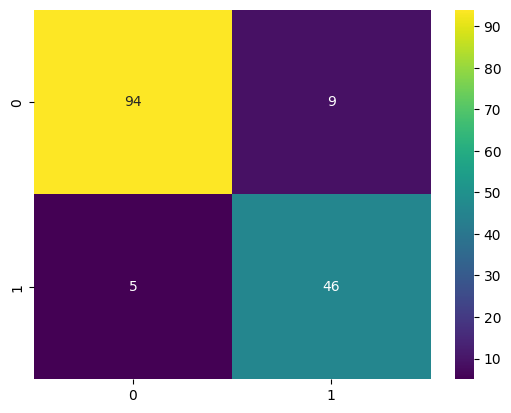

In [ ]:
confusion_matrix = confusion_matrix(model.predict(x_test),y_test)
sb.heatmap(confusion_matrix,annot=True,fmt="0.2g",cmap="viridis")
plt.show()

In [ ]:
print(classification_report(model.predict(x_test),y_test))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       103
           1       0.84      0.90      0.87        51

    accuracy                           0.91       154
   macro avg       0.89      0.91      0.90       154
weighted avg       0.91      0.91      0.91       154



In [ ]:
import joblib
# Save the tuned, fitted model
joblib.dump(model, "pima.pkl")

['pima.pkl']

In [ ]:
print(x_train.shape)
print(x_train.columns)


(614, 21)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'N1', 'N2', 'N3', 'N6', 'N7',
       'N9', 'N10', 'N11', 'N0', 'N8', 'N13', 'N12', 'N15'],
      dtype='object')
